## 주요 변경점 및 결과
1. Teacher Model Selection을 위한 Model Sweep

In [1]:
import os
os.environ['CUDA_MPS_PIPE_DIRECTORY'] = '/tmp/nvidia-mps'
os.environ['CUDA_MPS_LOG_DIRECTORY'] = '/tmp/nvidia-mps-log'

## 1. 라이브러리 및 환경 설정

In [ ]:
import os
import sys
import json
import random
import pandas as pd
import numpy as np
import cv2
import shutil
import timm
import wandb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from pathlib import Path

ROOT = Path.cwd().resolve().parent
SRC_DIR = (Path.cwd() / '../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from augmentations import build_default_transforms
from output_paths import allocate_output_paths
from reproducibility import make_generator, seed_everything, seed_worker

# /src 에서 실행하는 기준 경로 설정
DATA_DIR = (Path.cwd() / '../data').resolve()
EXPERIMENT_NAME = "Teacher_Model_Comp"
EXPERIMENT_VERSION = "v1"
WEIGHT_DIR = ROOT / "outputs" / "weights" / EXPERIMENT_NAME / EXPERIMENT_VERSION
SUBMISSION_DIR = ROOT / "outputs" / "submissions" / EXPERIMENT_NAME / EXPERIMENT_VERSION
EDA_DIR = ROOT / "outputs" / "eda_preprocessing" / EXPERIMENT_NAME / EXPERIMENT_VERSION
WEIGHT_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)
EDA_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.exists(), f"data 폴더를 찾지 못했습니다: {DATA_DIR}"
print(f"DATA_DIR: {DATA_DIR}")

# 하이퍼파라미터 설정
CFG = {
    # Basic
    'IMG_SIZE': 320,
    'EPOCHS': [30, 50, 100],
    'LEARNING_RATE': 3e-4,
    'MIN_LR': 1e-6,
    'BATCH_SIZE': 64,
    'SEED': 42,
    'NUM_WORKERS': 16,
    'USE_AMP' : True,
    # Regularization & Stability
    'WEIGHT_DECAY': 1e-4,  # L2 regularization
    'TEMPERATURE' : 2.0,
    'EMA_DECAY': 0.999, # 시계열에서 window size만큼 고려해 지역적 평균 구하는 방식으로 노이즈를 제거
    'EMA_USE_FOR_EVAL': True,
    'PATIENCE' : 10,
    # Augmentation & TTA
    'TTA_CANDIDATES': [ # TEST TIME AUGMENTATION
        ['none'],
        ['none', 'hflip'],
        ['none', 'hflip', 'crop95'],
    ],
}

BACKBONE_CANDIDATES = [
    "efficientnetv2_rw_m",
    "convnext_base.fb_in22k_ft_in1k",
    "swin_base_patch4_window7_224.ms_in22k_ft_in1k",
    "vit_small_patch14_dinov2.lvd142m",
    "depth_anything_small"
]

selected_backbones = []

for name in BACKBONE_CANDIDATES:
    if "depth_anything_small" in name:
        selected_backbones.append(name)
        continue
    try:
        timm.create_model(name, pretrained=False, num_classes=0, global_pool="")
        selected_backbones.append(name)
    except Exception as exc:
        print(f"skip backbone: {name}, reason: {exc}")

print("selected_backbones:", selected_backbones)
assert selected_backbones, "No candidate backbones are available in this timm installation."

seed_everything(CFG['SEED'])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

skip backbone: depth_anything_small Unknown model (depth_anything_small)
selected_backbones: ['efficientnetv2_rw_m', 'convnext_base.fb_in22k_ft_in1k', 'swin_base_patch4_window7_224.ms_in22k_ft_in1k', 'vit_small_patch14_dinov2.lvd142m']
cuda


## 2. 데이터 로드 및 학습/검증 데이터 분할

In [3]:
# 1. 데이터 로드
train_df = pd.read_csv(DATA_DIR / 'train.csv', encoding='utf-8-sig')
val_df = pd.read_csv(DATA_DIR / 'dev.csv', encoding='utf-8-sig')

print(f"학습 데이터 개수: {len(train_df)}")
print(f"검증 데이터 개수: {len(val_df)}")

학습 데이터 개수: 1000
검증 데이터 개수: 100


## 3-1. CheckerboardTopNormalizer 클래스 & CheckerboardTopNormConfig 설정 정의

In [4]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Optional
from PIL import Image

import cv2
import numpy as np
import matplotlib.pyplot as plt

@dataclass(frozen=True)
class CheckerboardTopNormConfig:
    enabled: bool = True
    ring_ratio: float = 0.10
    rot_line_min: int = 10
    rot_conf_min: float = 0.20
    pad_value: int = 128

def _estimate_mask(rgb: np.ndarray) -> np.ndarray:
    """
    지저분한 마스크 다듬기 & 원하는 물체만 골라내기
    """
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY) 
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV) 
    sat = hsv[:, :, 1]
    val = hsv[:, :, 2]

    s_thr = float(np.percentile(sat, 60.0))
    g_thr = float(np.percentile(gray, 45.0))
    v_thr = float(np.percentile(val, 35.0))

    mask = ((sat > s_thr) | (gray < g_thr) | (val < v_thr)).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)

    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
    if n <= 1:
        return (mask > 0).astype(np.uint8)

    best = 1
    best_area = 0
    h, w = gray.shape
    for i in range(1, n):
        x, y, ww, hh, area = stats[i].tolist()
        if area > best_area and ww > 8 and hh > 8 and area < 0.995 * h * w:
            best = i
            best_area = area
    return (labels == best).astype(np.uint8)


def _ring_mask(h: int, w: int, ratio: float) -> np.ndarray:
    r = max(1, int(round(min(h, w) * ratio)))
    mask = np.zeros((h, w), dtype=np.uint8)
    mask[:r, :] = 1
    mask[-r:, :] = 1
    mask[:, :r] = 1
    mask[:, -r:] = 1
    return mask


def _line_angles(edge: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    추출한 Edge 이미지에서 직선을 찾고, 기울어진 각을 계산해 반환하는 함수
    """
    lines = cv2.HoughLinesP(edge, 1, np.pi / 180.0, threshold=30, minLineLength=24, maxLineGap=6)
    if lines is None or len(lines) == 0:
        return np.zeros((0,), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    angs = []
    lens = []
    for line in lines[:400]:
        x1, y1, x2, y2 = line[0].tolist()
        dx = float(x2 - x1)
        dy = float(y2 - y1)
        ln = float(np.hypot(dx, dy))
        if ln < 8:
            continue
        ang = (float(np.degrees(np.arctan2(dy, dx))) + 180.0) % 180.0
        angs.append(ang)
        lens.append(ln)
    if len(angs) == 0:
        return np.zeros((0,), dtype=np.float32), np.zeros((0,), dtype=np.float32)
    return np.asarray(angs, dtype=np.float32), np.asarray(lens, dtype=np.float32)


def estimate_top_rotation(rgb: np.ndarray, cfg: CheckerboardTopNormConfig) -> dict[str, float | bool | int | str]:
    h, w = rgb.shape[:2]
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    fg = _estimate_mask(rgb) # 원하는 물체를 추출하는 함수
    bg = (1 - fg).astype(np.uint8)
    if int(bg.sum()) < int(0.03 * h * w):
        bg = _ring_mask(h, w, cfg.ring_ratio)

    gx = cv2.Scharr(gray, cv2.CV_32F, 1, 0)
    gy = cv2.Scharr(gray, cv2.CV_32F, 0, 1)
    mag = cv2.magnitude(gx, gy)
    mag = (mag / (mag.max() + 1e-6) * 255.0).astype(np.uint8)
    edges = cv2.Canny(mag, 40, 120)
    edges = cv2.bitwise_and(edges, edges, mask=(bg * 255))

    angles, lengths = _line_angles(edges)
    line_n = int(len(angles))
    if line_n == 0:
        return {
            "angle_deg": 0.0,
            "rot_conf": 0.0,
            "rot_ok": False,
            "rot_fail_reason": "no_lines",
            "rot_line_count": 0,
        }

    hist, _ = np.histogram(angles, bins=180, range=(0.0, 180.0), weights=lengths)
    peak_primary = int(np.argmax(hist))
    peak_primary_value = float(hist[peak_primary])

    hist_secondary = hist.copy()
    for d in range(-8, 9):
        hist_secondary[(peak_primary + d) % 180] = 0.0
    peak_secondary = int(np.argmax(hist_secondary))
    peak_secondary_value = float(hist_secondary[peak_secondary])
    peak_orthogonal = float(hist[(peak_primary + 90) % 180])

    mods = np.mod(angles, 90.0)
    theta = mods * (2.0 * np.pi / 90.0)
    cx = float(np.sum(lengths * np.cos(theta)))
    cy = float(np.sum(lengths * np.sin(theta)))
    rot_mod90 = float((np.degrees(np.arctan2(cy, cx)) * (90.0 / 360.0)) % 90.0)

    peak_ratio_score = peak_primary_value / (peak_primary_value + peak_secondary_value + 1e-6)
    line_score = min(1.0, line_n / 60.0)
    spread = float(np.sqrt(np.average((mods - np.average(mods, weights=lengths)) ** 2, weights=lengths)))
    spread_score = float(np.clip(1.0 - spread / 20.0, 0.0, 1.0))
    ortho_score = float(np.clip(peak_orthogonal / (peak_primary_value + 1e-6), 0.0, 1.0))
    conf = float(np.clip(0.35 * peak_ratio_score + 0.25 * line_score + 0.20 * spread_score + 0.20 * ortho_score, 0.0, 1.0))

    reasons = []
    if line_n < cfg.rot_line_min:
        reasons.append("line_count_low")
    if conf < cfg.rot_conf_min:
        reasons.append("confidence_low")

    return {
        "angle_deg": -rot_mod90,
        "rot_conf": conf,
        "rot_ok": len(reasons) == 0,
        "rot_fail_reason": "|".join(reasons),
        "rot_line_count": line_n,
    }

def rotate_rgb(rgb: np.ndarray, angle_deg: float, pad_value: int) -> np.ndarray:
    if abs(angle_deg) < 1e-6:
        return rgb
    h, w = rgb.shape[:2]
    matrix = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), angle_deg, 1.0)
    return cv2.warpAffine(
        rgb,
        matrix,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(pad_value, pad_value, pad_value),
    )


class CheckerboardTopNormalizer:
    def __init__(self, cfg: Optional[CheckerboardTopNormConfig] = None) -> None:
        self.cfg = cfg or CheckerboardTopNormConfig()
        self._angle_cache: Dict[str, Optional[float]] = {}

    def normalize(self, path: str | Path, image: Image.Image, debug_save_path: Optional[Path] = None) -> Image.Image:
            """
            이미지를 정규화(회전 보정)합니다.
            debug_save_path가 전달되면 중간 분석 과정을 시각화하여 저장합니다.
            """
            if not self.cfg.enabled:
                return image

            key = str(Path(path).expanduser().resolve())
            
            # 1. 각도 계산 및 캐싱 (이미 계산된 적이 없다면 실행)
            if key not in self._angle_cache:
                rgb = np.asarray(image.convert("RGB"))
                info = estimate_top_rotation(rgb, self.cfg)
                
                # 성공 여부에 따라 각도 저장 (실패 시 None)
                self._angle_cache[key] = float(info["angle_deg"]) if bool(info["rot_ok"]) else None

                # [핵심 수정] 파라미터로 받은 debug_save_path가 있을 때만 시각화 함수 호출
                if debug_save_path:
                    self._save_debug_plot(rgb, info, debug_save_path)

            # 2. 캐시된 각도 가져오기
            angle = self._angle_cache[key]
            
            # 보정할 각도가 없거나(None), 실패한 경우 원본 반환
            if angle is None:
                return image

            # 3. 실제 회전 적용
            rgb = np.asarray(image.convert("RGB"))
            rotated = rotate_rgb(rgb, angle_deg=angle, pad_value=self.cfg.pad_value)
            
            return Image.fromarray(rotated)
    
    def _save_debug_plot(self, rgb: np.ndarray, info: dict, save_path: Path):
        # 중간 과정 재현 (시각화용)
        fg_mask = _estimate_mask(rgb)
        bg_mask = (1 - fg_mask).astype(np.uint8)
        if int(bg_mask.sum()) < int(0.03 * rgb.shape[0] * rgb.shape[1]):
            bg_mask = _ring_mask(rgb.shape[0], rgb.shape[1], self.cfg.ring_ratio)
        
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 40, 120) # 단순화를 위해 바로 Canny 적용 가능
        masked_edges = cv2.bitwise_and(edges, edges, mask=(bg_mask * 255))
        
        line_img = rgb.copy()
        lines = cv2.HoughLinesP(masked_edges, 1, np.pi / 180.0, threshold=30, minLineLength=24, maxLineGap=6)
        if lines is not None:
            for line in lines[:100]:
                x1, y1, x2, y2 = line[0]
                cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        rotated = rotate_rgb(rgb, info["angle_deg"], self.cfg.pad_value)

        # 플롯 생성
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        titles = ["Original", "Edges", "Lines", "Result"]
        imgs = [rgb, masked_edges, line_img, rotated]
        
        for ax, img, title in zip(axes, imgs, titles):
            ax.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
            ax.set_title(title)
            ax.axis('off')
        
        fig.suptitle(f"Angle: {info['angle_deg']:.2f}° | Conf: {info['rot_conf']:.2f}", fontsize=15)
        
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight')
        plt.close(fig)

## 3-2. CheckerboardTopNormalization을 포함한 커스텀 데이터셋 클래스 정의 및 데이터 로더

In [5]:
class MultiViewDataset(Dataset):
    def __init__(
        self,
        df,
        root_dir,
        transform=None, # 이 transform이 Compose라면 내부 시점별 분기가 필요할 수 있음
        is_test=False,
        feature_dir=None,
        checkerboard_top_normalize: bool = True
    ):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform
        self.is_test = is_test
        self.label_map = {'stable': 0, 'unstable': 1}
        
        # 체커보드 정규화기 설정
        self.top_normalizer = CheckerboardTopNormalizer(
            CheckerboardTopNormConfig(enabled=True)
        ) if checkerboard_top_normalize else None

    def __len__(self):
        return len(self.df)

    def _load_img(self, sid: str, view: str, sample_dir: str) -> Image.Image:
        # 비디오 증강 데이터 여부 확인 (ID prefix 사용)
        is_augv = sid.startswith('AUGV_')
        
        # 경로 설정
        path = Path(sample_dir) / sid / f"{view}.png"
        image = Image.open(path).convert("RGB")
        
        # [핵심 수정] Top View 정규화 로직 - 비디오 증강 데이터(AUGV_)가 아닐 때만 체커보드 정규화 수행
        if view == "top" and self.top_normalizer is not None and not is_augv:
            debug_path = None
            # 학습/검증 중 앞부분만 디버깅 이미지 저장
            if not self.is_test and len(self.top_normalizer._angle_cache) < 20:
                folder = "train" if "TRAIN" in sid else "dev"
                debug_path = Path(f"./debug_plots/{folder}/{sid}_top.png")

            image = self.top_normalizer.normalize(path, image, debug_save_path=debug_path)
            
        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sid = str(row['id'])
        # sample_dir이 row에 있으면 사용, 없으면 기본 root_dir 사용
        sample_dir = row['sample_dir'] if 'sample_dir' in row else self.root_dir

        views = []
        for name in ['front', 'top']:
            # 정규화 로직이 포함된 이미지 로드 호출
            image = self._load_img(sid, name, sample_dir)
            
            # transform 적용
            if self.transform:
                # 만약 transform이 시점별로 다르다면(Compose 내부 분기 등) 여기서 처리
                image = self.transform(image)
            
            views.append(image)

        if self.is_test:
            return views

        label = self.label_map[row['label']]
        return views, label

In [6]:
train_transform, test_transform = build_default_transforms(CFG['IMG_SIZE'])

# 원본 학습 데이터(기본 1:1)
train_df_for_train = train_df.copy()
train_df_for_train['sample_dir'] = str(DATA_DIR / 'train')

# 최종 학습 비율 확인
print('Final train class ratio:')
print(train_df_for_train['label'].value_counts())

Final train class ratio:
label
unstable    500
stable      500
Name: count, dtype: int64


In [7]:
val_df_for_eval = val_df.copy()
val_df_for_eval['sample_dir'] = str(DATA_DIR / 'dev')

# 1. 학습/검증 세트 준비
train_dataset = MultiViewDataset(train_df_for_train, str(DATA_DIR / 'train'), train_transform, is_test=False)
val_dataset = MultiViewDataset(val_df_for_eval, str(DATA_DIR / 'dev'), test_transform, is_test=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'),
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'])
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'),
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'] + 1)
)

# 2. 테스트 세트 준비
test_df = pd.read_csv(DATA_DIR / 'sample_submission.csv', encoding='utf-8-sig')
test_df_for_infer = test_df.copy()
test_df_for_infer['sample_dir'] = str(DATA_DIR / 'test')

test_dataset = MultiViewDataset(test_df_for_infer, str(DATA_DIR / 'test'), test_transform, is_test=True)
test_loader = DataLoader(
    test_dataset,
    batch_size=CFG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CFG['NUM_WORKERS'],
    pin_memory=(device.type == 'cuda'),
    worker_init_fn=seed_worker,
    generator=make_generator(CFG['SEED'] + 2)
)

## 4. 모델 정의 (Multi-View )

In [8]:
from models import (
    EMAConfig,
    ModelEMA,
)
import dataclasses

EMA_CONFIG = EMAConfig(decay=CFG['EMA_DECAY'])
artifacts = allocate_output_paths(experiment_name='baseline_checkerboard_norm', major_version='v1.0')

In [ ]:
from transformers import AutoModel
import os

DEPTH_ANYTHING_MODEL_DIR = "/home/vsc/LLM/model/Depth-Anything-V2-Small"

@dataclass(frozen=True)
class FlexibleMultiViewFeatureFusionConfig:
    backbone_name: str = "efficientnetv2_rw_s"
    pretrained: bool = True
    hidden_dim: int = 512
    mid_dim: int = 128
    dropout: float = 0.3
    out_dim: int = 1

class FlexibleMultiViewFeatureFusion(nn.Module):
    def __init__(self, config: FlexibleMultiViewFeatureFusionConfig):
        super().__init__()
        self.config = config
        
        # 1. 백본 로드 (timm vs Hugging Face 분기)
        if "depth_anything_small" in config.backbone_name:
            # DepthAnything 모델 로드 (Hugging Face)
            if not os.path.exists(DEPTH_ANYTHING_MODEL_DIR):
                raise FileNotFoundError(f"로컬 모델 경로를 찾을 수 없습니다: {DEPTH_ANYTHING_MODEL_DIR}")
                
            self.backbone = AutoModel.from_pretrained(DEPTH_ANYTHING_MODEL_DIR)
            self.feat_dim = 384 # depth-anything-small(DINOv2 small)의 Feature 차원
            
        else:
            # 일반 timm 모델 로드
            self.backbone = timm.create_model(
                config.backbone_name, 
                pretrained=config.pretrained, 
                num_classes=0,
                global_pool="" 
            )     
            # 백본별 고유 출력 차원 추출 (Swin: 768, ConvNeXt: 768, EfficientNet: 1280 등)
            self.feat_dim = self.backbone.num_features

        self.fusion = nn.Sequential(
            nn.Linear(self.feat_dim * 4, config.hidden_dim),
            nn.BatchNorm1d(config.hidden_dim), # 백본마다 값의 스케일이 다르므로 BN 추가 강력 권장
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dim, config.mid_dim),
            nn.ReLU()
        )
        
        # distillation용 projection: student feature → 768dim (VideoMAE와 맞춤)
        self.distill_proj = nn.Linear(config.mid_dim, 768)
        self.head = nn.Linear(config.mid_dim, config.out_dim)

    def _extract_and_pool(self, x: torch.Tensor) -> torch.Tensor:
        """
        입력된 텐서의 형태(CNN, Swin, ViT)를 동적으로 파악하여
        (Batch, Feature_Dim) 크기의 1D 벡터로 Global Average Pooling을 수행합니다.
        """
        feat = self.backbone.forward_features(x)

        # 1. 4D Tensor (CNN 또는 Swin)
        if feat.ndim == 4:
            # (B, C, H, W) 형태인 경우 (EfficientNet, ConvNeXt 등)
            if feat.shape[1] == self.feat_dim:
                return feat.mean(dim=(2, 3))
            
            # (B, H, W, C) 형태인 경우 (특정 버전의 Swin 등)
            elif feat.shape[-1] == self.feat_dim:
                return feat.mean(dim=(1, 2))

        # 2. 3D Tensor (ViT 등 Sequence 형태: (B, Sequence_Length, C))
        elif feat.ndim == 3:
            if feat.shape[-1] == self.feat_dim:
                return feat.mean(dim=1) # 모든 토큰의 평균을 냄 (GAP)

        raise ValueError(f"Unsupported feature shape: {tuple(feat.shape)} for backbone={self.config.backbone_name}")

    def forward(self, views, return_feat=False):
        # 2. 백본을 거쳐 무조건 (B, feat_dim) 형태로 맞춰진 특징 벡터 획득
        f1 = self._extract_and_pool(views[0])
        f2 = self._extract_and_pool(views[1])

        combined = torch.cat([f1, f2, torch.abs(f1 - f2), f1 * f2], dim=1)
        
        # 3. 차원에 구애받지 않고 안전하게 Concat 진행
        fused = self.fusion(combined)  # (B, mid_dim)
        out   = self.head(fused)                         # (B, 1)

        if return_feat:
            student_feat = self.distill_proj(fused)      # (B, 768)
            return out, student_feat

        return out

## 4. 학습 및 검증 루프 구현

In [10]:
from torch.cuda.amp import autocast, GradScaler

def train_one_epoch(model, loader, criterion, optimizer, device, ema=None, scaler=None, epoch=0):
    model.train()
    epoch_total_loss = 0

    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"Epoch {epoch}", dynamic_ncols=True, ascii=True)

    for i, (views, labels) in pbar :
        views = [v.to(device) for v in views]
        labels = labels.to(device).float()

        optimizer.zero_grad()

        with autocast() :
            outputs = model(views).view(-1)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        if ema is not None:
            ema.update(model)

        epoch_total_loss += loss.item()

    num_batches = len(loader)
    avg_total = epoch_total_loss / num_batches

    print(f"\n>> [Epoch {epoch} Summary] | Total Loss:   {avg_total:.6f} |  Learning Rate: {optimizer.param_groups[0]['lr']:.8f}")

    wandb.log({
        'train/epoch_total_loss': avg_total,
        'epoch': epoch
    })

    return avg_total


def validate(model, loader, criterion, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for views, labels in tqdm(loader, desc="Validation", dynamic_ncols=True, ascii=True):
            views = [v.to(device) for v in views]
            labels = labels.to(device).float()

            outputs = model(views).view(-1)
            probs = torch.sigmoid(outputs)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs, dtype=np.float64)
    all_labels = np.array(all_labels, dtype=np.float64)

    eps = 1e-15
    p = np.clip(all_probs, eps, 1 - eps)
    logloss_score = -np.mean(all_labels * np.log(p) + (1 - all_labels) * np.log(1 - p))
    acc_score = np.mean((all_probs > 0.5) == all_labels)

    return logloss_score, acc_score


# -------------------------
# TTA helpers
# -------------------------
def _center_crop_and_resize(x, crop_ratio=0.95):
    # x: [B, C, H, W]
    b, c, h, w = x.shape
    ch, cw = int(h * crop_ratio), int(w * crop_ratio)
    y1 = (h - ch) // 2
    x1 = (w - cw) // 2
    cropped = x[:, :, y1:y1 + ch, x1:x1 + cw]
    return F.interpolate(cropped, size=(h, w), mode='bilinear', align_corners=False)


def apply_tta_to_views(views, tta_name):
    if tta_name == 'none':
        return views
    if tta_name == 'hflip':
        return [torch.flip(v, dims=[3]) for v in views]
    if tta_name == 'crop95':
        return [_center_crop_and_resize(v, crop_ratio=0.95) for v in views]
    raise ValueError(f'Unknown TTA: {tta_name}')


def predict_probs_with_tta(model, loader, device, tta_names=None, has_labels=False, desc='Inference TTA'):
    if tta_names is None:
        tta_names = ['none']

    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, dynamic_ncols=True, ascii=True):
            if has_labels:
                views, labels = batch
                labels = labels.to(device).float()
                all_labels.extend(labels.cpu().numpy())
            else:
                views = batch

            views = [v.to(device) for v in views]

            probs_sum = None
            for tta_name in tta_names:
                tta_views = apply_tta_to_views(views, tta_name)
                logits = model(tta_views).view(-1)
                probs = torch.sigmoid(logits)
                probs_sum = probs if probs_sum is None else (probs_sum + probs)

            probs_avg = probs_sum / len(tta_names)
            all_probs.extend(probs_avg.cpu().numpy())

    all_probs = np.array(all_probs, dtype=np.float64)
    if has_labels:
        return all_probs, np.array(all_labels, dtype=np.float64)
    return all_probs


def evaluate_tta_on_dev(model, loader, device, tta_candidates):
    rows = []
    for tta_names in tta_candidates:
        probs, labels = predict_probs_with_tta(
            model, loader, device, tta_names=tta_names, has_labels=True,
            desc=f'Dev TTA {tta_names}'
        )

        eps = 1e-15
        p = np.clip(probs, eps, 1 - eps)
        logloss_score = -np.mean(labels * np.log(p) + (1 - labels) * np.log(1 - p))
        acc_score = np.mean((probs > 0.5) == labels)

        rows.append({
            'tta_names': tta_names,
            'n_tta': len(tta_names),
            'val_logloss': float(logloss_score),
            'val_acc': float(acc_score),
        })

    return pd.DataFrame(rows).sort_values('val_logloss', ascending=True).reset_index(drop=True)

In [11]:
def train_single_backbone(backbone_name : str) :
    safe_name = backbone_name.replace("/", "_").replace(".", "_")
    sweep_results = []
    epochs_list = CFG['EPOCHS']

    for target_epochs in epochs_list :
        print(f"\n=======================================================")
        print(f"🚀 Starting Sweep: {backbone_name} | EPOCHS = {target_epochs}")
        print(f"=======================================================\n")

        best_model_path = WEIGHT_DIR / f"best_model_{safe_name}_{target_epochs}.pt"
        submission_path = SUBMISSION_DIR / f"submission_{safe_name}_{target_epochs}.csv"

        run_name = f"{safe_name}_ep{target_epochs}"
        wandb.init(
            project="structure-stability", 
            name=f"{run_name}",
            group=EXPERIMENT_NAME,
            config=CFG,
            reinit=True # 중요: 이전 Run을 닫고 새로 시작
        )

        model_config = FlexibleMultiViewFeatureFusionConfig(backbone_name = backbone_name)
        print(model_config)
        model = FlexibleMultiViewFeatureFusion(model_config).to(device)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=CFG['LEARNING_RATE'], weight_decay=CFG['WEIGHT_DECAY'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=target_epochs, eta_min=CFG['MIN_LR']
        )
        ema = ModelEMA(model, EMA_CONFIG)

        print(f"Artifact version: {artifacts['version']}")
        print(f"Regularization -> weight_decay={CFG['WEIGHT_DECAY']}")
        print(f"Scheduler -> CosineAnnealingLR(T_max={target_epochs}, eta_min={CFG['MIN_LR']})")
        print(f"EMA -> decay={CFG['EMA_DECAY']}, use_for_eval={CFG['EMA_USE_FOR_EVAL']}")
        print(f"Early Stopping -> Patience={CFG['PATIENCE']}")

        # --- Init ---
        best_epoch = -1
        early_stop_counter = 0 
        best_logloss = float('inf')
        scaler = GradScaler()

         # --- Main Loop ---
        for epoch in range(1, target_epochs + 1):
            avg_train_loss = train_one_epoch(
                model, train_loader, criterion, optimizer, device,
                ema=ema,
                scaler=scaler,
                epoch = epoch  
            )
            
            eval_model = ema.ema_model if CFG['EMA_USE_FOR_EVAL'] else model
            val_logloss, val_acc = validate(eval_model, val_loader, criterion, device)

            # WandB 기록
            wandb.log({
                'epoch'          : epoch,
                'val/logloss'    : val_logloss,
                'val/acc'        : val_acc,
                'lr'             : optimizer.param_groups[0]['lr'],
                'best_logloss'   : best_logloss,
                'early_stop_count': early_stop_counter
            }, step=epoch)

            # --- Early Stopping 및 모델 저장 로직 ---
            if val_logloss < best_logloss:
                # 성능 개선됨
                best_logloss = val_logloss
                best_epoch = epoch
                early_stop_counter = 0  # 개선되었으므로 카운터 초기화
                
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'ema_state_dict': ema.ema_model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_logloss': val_logloss,
                    'val_acc': val_acc,
                    'cfg': CFG,
                }, best_model_path)
                print(f"  -> Best model saved: {best_model_path} (epoch={epoch}, val_logloss={val_logloss:.6f})")
            else:
                # 성능 개선 없음
                early_stop_counter += 1
                print(f"  -> No improvement. EarlyStopping counter: {early_stop_counter}/{CFG['PATIENCE']}")

            # 조기 종료 체크
            if early_stop_counter >= CFG['PATIENCE']:
                print(f" \n! [Early Stopping] Training stopped at epoch {epoch}. Best Epoch was {best_epoch}.")
                break

            scheduler.step()
            current_lr = optimizer.param_groups[0]['lr']

            print(f"Epoch [{epoch}]")
            print(f"  - LR: {current_lr:.8f}")
            print(f"  - Train Loss: {avg_train_loss:.4f}")
            print(f"  - Val Log-Loss: {val_logloss:.6f} | Val Acc: {val_acc:.4f}")

        wandb.finish()

        # 학습 종료 후 best 가중치 로드
        if best_model_path.exists():
            checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
            sweep_results.append({
                "backbone": backbone_name,
                "target_epochs": target_epochs,
                "best_epoch": checkpoint['epoch'],
                "val_logloss": checkpoint['val_logloss'],
                "val_acc": checkpoint['val_acc'],
                "model_path": str(best_model_path)
            })

    return sweep_results

In [ ]:
import pandas as pd

results = []

for backbone_name in selected_backbones:
    try:
        result_list = train_single_backbone(backbone_name)
        results.extend(result_list) 
        
    except Exception as exc:
        print(f"FAILED: {backbone_name} | Error: {exc}")

result_df = pd.DataFrame(results)
if not result_df.empty:
    result_df = result_df.sort_values(
        by=["val_logloss", "val_acc"], 
        ascending=[True, False]
    ).reset_index(drop=True)

    # 출력 및 저장
    display(result_df)
    
    # 저장할 디렉토리가 없다면 생성
    os.makedirs(EDA_DIR, exist_ok=True)
    result_df.to_csv(EDA_DIR / "mv_caf_ensemble_v1.0_eval.csv", index=False)
    print("✨ 모든 스윕 완료 및 결과 저장 성공!")
else:
    print("결과가 비어 있습니다. 학습 중 에러가 발생했는지 확인해주세요.")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/vsc/.netrc.



🚀 Starting Sweep: efficientnetv2_rw_m | EPOCHS = 30



wandb: Currently logged in as: jungseonglian (uailab-unist_) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


FlexibleMultiViewFeatureFusionConfig(backbone_name='efficientnetv2_rw_m', pretrained=True, hidden_dim=512, mid_dim=128, dropout=0.3, out_dim=1)


/home/vsc/LLM_TUNE/structure-stability/venv/venv-stability/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


Artifact version: v1.0.2
Regularization -> weight_decay=0.0001
Scheduler -> CosineAnnealingLR(T_max=30, eta_min=1e-06)
EMA -> decay=0.999, use_for_eval=True
Early Stopping -> Patience=10


/tmp/ipykernel_403271/2569331043.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1:   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipykernel_403271/1581096119.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast() :


## 5. 검증셋 오답 확인

학습된 모델이 `dev`에서 틀린 샘플을 표와 이미지로 확인합니다.

In [13]:
if 'best_tta_names' not in globals():
    best_tta_names = ['none']

val_probs, _ = predict_probs_with_tta(
    model, val_loader, device,
    tta_names=best_tta_names,
    has_labels=True,
    desc='Validate Error Analysis (TTA)'
)

val_result = val_df.copy().reset_index(drop=True)
val_result['unstable_prob'] = val_probs
val_result['stable_prob'] = 1.0 - val_probs
val_result['pred_label'] = np.where(val_result['unstable_prob'] > 0.5, 'unstable', 'stable')

mistakes = val_result[val_result['pred_label'] != val_result['label']].copy()
mistakes['pred_confidence'] = np.where(
    mistakes['pred_label'] == 'unstable',
    mistakes['unstable_prob'],
    mistakes['stable_prob']
)
mistakes = mistakes.sort_values('pred_confidence', ascending=False).reset_index(drop=True)

print(f"사용 TTA: {best_tta_names}")
print(f"오답 개수: {len(mistakes)} / {len(val_result)}")
display(mistakes[['id', 'label', 'pred_label', 'unstable_prob', 'stable_prob', 'pred_confidence']].head(20))

NameError: name 'model' is not defined

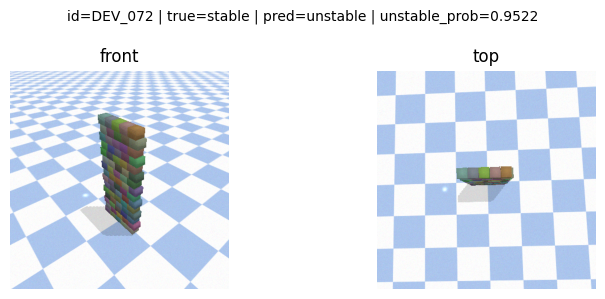

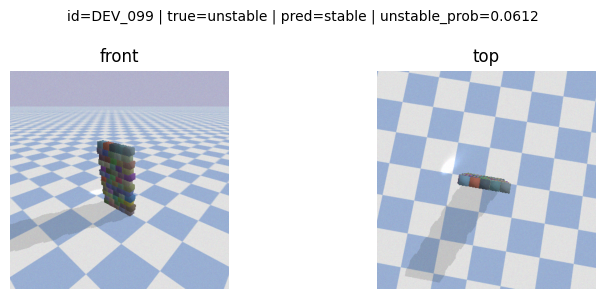

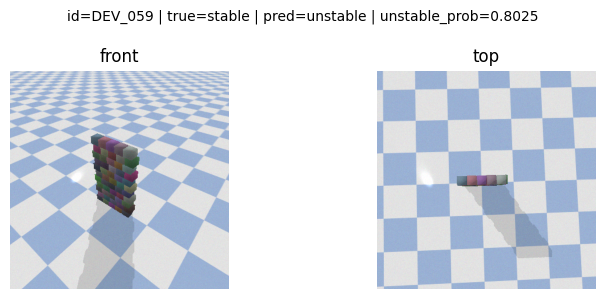

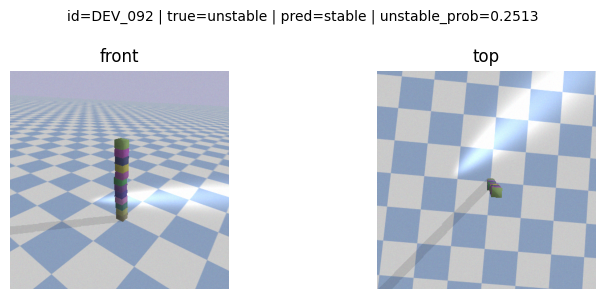

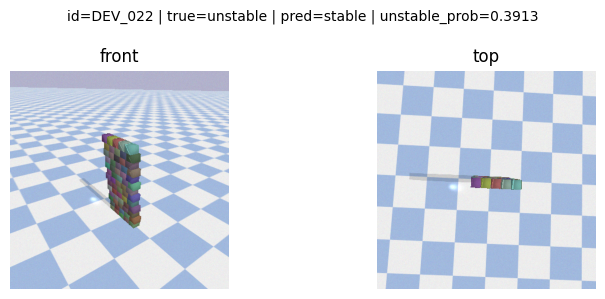

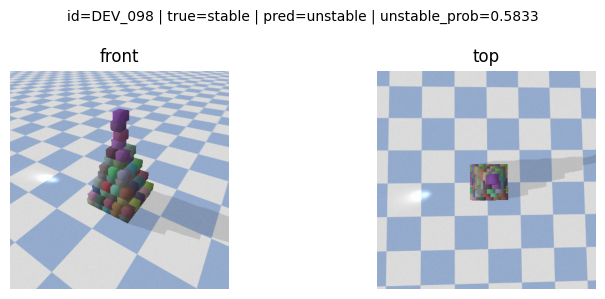

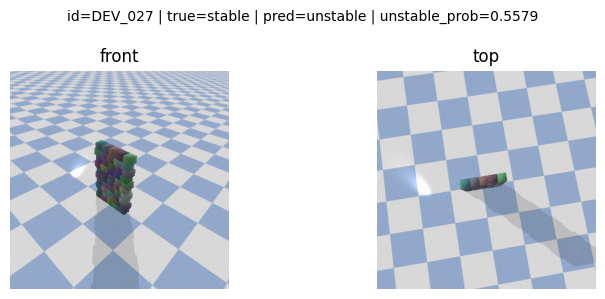

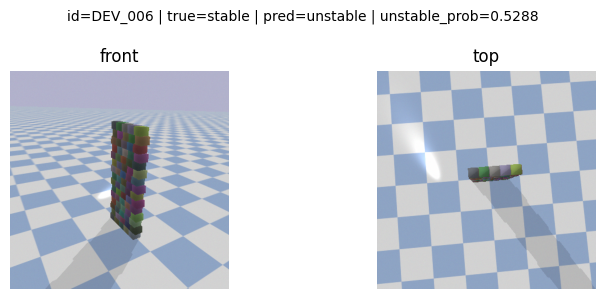

In [ ]:
import matplotlib.pyplot as plt

TOP_N = 8  # 시각화할 오답 샘플 수
show_df = mistakes.head(TOP_N)

for _, row in show_df.iterrows():
    sample_id = row['id']
    front_path = DATA_DIR / 'dev' / sample_id / 'front.png'
    top_path = DATA_DIR / 'dev' / sample_id / 'top.png'

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    axes[0].imshow(Image.open(front_path).convert('RGB'))
    axes[0].set_title('front')
    axes[0].axis('off')

    axes[1].imshow(Image.open(top_path).convert('RGB'))
    axes[1].set_title('top')
    axes[1].axis('off')

    fig.suptitle(
        f"id={sample_id} | true={row['label']} | pred={row['pred_label']} | unstable_prob={row['unstable_prob']:.4f}",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()



## 5. 추론 및 제출 파일 생성

In [ ]:
# 1) dev에서 TTA 조합 성능 비교
candidate_ttas = CFG['TTA_CANDIDATES']
tta_result_df = evaluate_tta_on_dev(model, val_loader, device, candidate_ttas)
display(tta_result_df)

best_tta_names = tta_result_df.iloc[0]['tta_names']
print(f"Best TTA on dev: {best_tta_names}")

# 2) best TTA로 test 추론
all_probs = predict_probs_with_tta(
    model, test_loader, device,
    tta_names=best_tta_names,
    has_labels=False,
    desc='Inference with TTA'
)

# 결과 저장
submission = pd.DataFrame({
    'id': test_df['id'],
    'unstable_prob': all_probs,
    'stable_prob': 1.0 - all_probs
})

submission.to_csv(submission_path, encoding='UTF-8-sig', index=False)
print(f'{submission_path} 저장 완료.')

Dev TTA ['none', 'hflip', 'crop95']: 100%|##########| 4/4 [00:13<00:00,  3.36s/it]


,tta_names,n_tta,val_logloss,val_acc
0,[none],1,0.218147,0.91
1,"[none, hflip, crop95]",3,0.220710,0.92
2,"[none, hflip]",2,0.222147,0.93


Best TTA on dev: ['none']


Inference with TTA: 100%|##########| 32/32 [00:21<00:00,  1.49it/s]

/home/vsc/LLM_TUNE/structure-stability/outputs/submissions/baseline_checkerboard_norm_v1.0.1.csv 저장 완료.
